In [1]:
import glob, os, pathlib, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['hatch.linewidth'] = 2.0

# ── Font size variables (adjust as needed) ──
YLABEL_FONTSIZE = 28
YTICK_FONTSIZE = 24
TITLE_FONTSIZE = 28
LEGEND_FONTSIZE = 28

SYSTEM_STYLE = {
    'ShuntServe': {'color': '#3498db', 'hatch': '/'},
    'HexGen':     {'color': '#1abc9c', 'hatch': '\\'},
    'AlpaServe':  {'color': '#e91e63', 'hatch': 'x'},
    'vLLM':       {'color': '#9b59b6', 'hatch': '+'},
}
SYSTEM_ORDER = ['ShuntServe', 'HexGen', 'AlpaServe', 'vLLM']
SYSTEM_NAME_MAP = {
    'shuntserve': 'ShuntServe',
    'hexgen': 'HexGen',
    'alpaserve': 'AlpaServe',
    'vllm': 'vLLM',
}

# (csv_column, json_percentile_key, ylabel, file_suffix, csv_scale, json_scale)
# csv values are in seconds; json values are in ms
# csv_scale:  multiply CSV values by this to get target unit (seconds)
# json_scale: multiply JSON values (ms) by this to get target unit (seconds)
METRICS = [
    ('Latency', 'percentiles_e2el_ms', 'E2E Latency (s)', 'e2e',  1,     0.001),
    ('TTFT',    'percentiles_ttft_ms', 'TTFT (s)',         'ttft', 1,     0.001),
    ('TPOT',    'percentiles_tpot_ms', 'TPOT (s)',         'tpot', 1,     0.001),
]

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
FIG_DIR = os.path.join(BASE_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)


def plot_online_boxplot(model, metric_idx=None, t_start_min=0, t_end_min=18,
                        show_title=False, source='csv'):
    """Plot online latency distributions as box plots.

    metric_idx: None  — plot all metrics (one figure each)
                0/1/2 — plot only that metric (E2E / TTFT / TPOT)
    source: 'csv'  — compute percentiles from CSV per-request data over [t_start_min, t_end_min)
            'json' — use pre-computed percentiles from JSON benchmark results
    """
    model_dir = os.path.join(BASE_DIR, 'online', model)
    model_safe = model.replace('-', '_')
    metrics_to_plot = [METRICS[metric_idx]] if metric_idx is not None else METRICS

    # Collect per-system box stats for each metric
    box_data = [{} for _ in METRICS]

    if source == 'json':
        json_dir = os.path.join(model_dir, 'json')
        json_files = sorted(glob.glob(os.path.join(json_dir, '*.json')))
        if not json_files:
            print(f'No JSON files found in {json_dir}')
            return

        for jp in json_files:
            stem = pathlib.Path(jp).stem.replace('online_', '')
            sys_name = SYSTEM_NAME_MAP.get(stem)
            if sys_name is None:
                continue
            with open(jp) as f:
                d = json.load(f)

            for mi, (_, json_key, _, _, _, jscale) in enumerate(METRICS):
                p = d[json_key]
                box_data[mi][sys_name] = {
                    'whislo': p['10'] * jscale, 'q1': p['25'] * jscale, 'med': p['50'] * jscale,
                    'q3': p['75'] * jscale, 'whishi': p['90'] * jscale,
                }
            print(f'  {sys_name:12s}: loaded from JSON')

    else:  # csv
        csv_dir = os.path.join(model_dir, 'csv')
        csv_files = sorted(glob.glob(os.path.join(csv_dir, '*.csv')))
        if not csv_files:
            print(f'No CSV files found in {csv_dir}')
            return

        for csv_path in csv_files:
            stem = pathlib.Path(csv_path).stem
            sys_name = SYSTEM_NAME_MAP.get(stem)
            if sys_name is None:
                continue

            df = pd.read_csv(csv_path)
            t0 = df['ArrivalTime'].min()
            t_rel = df['CompletionTime'] - t0
            mask = (t_rel >= t_start_min * 60) & (t_rel < t_end_min * 60)
            sub = df[mask]

            if len(sub) == 0:
                print(f'  {sys_name:12s}: no data in [{t_start_min}-{t_end_min}) min')
                continue

            for mi, (col, _, _, _, cscale, _) in enumerate(METRICS):
                vals = sub[col] * cscale
                box_data[mi][sys_name] = {
                    'whislo': vals.quantile(0.10),
                    'q1':     vals.quantile(0.25),
                    'med':    vals.quantile(0.50),
                    'q3':     vals.quantile(0.75),
                    'whishi': vals.quantile(0.90),
                }
            print(f'  {sys_name:12s}: {len(sub):5d} completed in [{t_start_min}-{t_end_min}) min')

    # Determine which systems have data
    systems = [s for s in SYSTEM_ORDER if s in box_data[0]]
    if not systems:
        print('No data to plot.')
        return

    # Draw one figure per metric
    for col, json_key, ylabel, file_suffix, _, _ in metrics_to_plot:
        mi = next(i for i, m in enumerate(METRICS) if m[0] == col)

        fig, ax = plt.subplots(figsize=(7, 4.5))
        x_positions = np.arange(len(systems))

        for i, sys in enumerate(systems):
            stats = box_data[mi][sys]
            style = SYSTEM_STYLE[sys]

            bxp_stats = [{
                'whislo': stats['whislo'],
                'q1':     stats['q1'],
                'med':    stats['med'],
                'q3':     stats['q3'],
                'whishi': stats['whishi'],
                'fliers': [],
            }]

            bp = ax.bxp(
                bxp_stats,
                positions=[x_positions[i]],
                widths=0.5,
                showfliers=False,
                patch_artist=True,
                manage_ticks=False,
            )

            for box in bp['boxes']:
                box.set_facecolor(style['color'])
                box.set_alpha(0.8)
                box.set_edgecolor('black')
                box.set_linewidth(0.5)
                box.set_hatch(style['hatch'])
            for median in bp['medians']:
                median.set_color('red')
                median.set_linewidth(2)
            for whisker in bp['whiskers']:
                whisker.set_color('black')
                whisker.set_linewidth(1)
            for cap in bp['caps']:
                cap.set_color('black')
                cap.set_linewidth(1)

        ax.set_ylabel(ylabel, fontsize=YLABEL_FONTSIZE)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([])
        ax.tick_params(axis='y', labelsize=YTICK_FONTSIZE)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_axisbelow(True)

        if show_title:
            title = f'{model} {file_suffix.upper()} (json)' if source == 'json' \
                else f'{model} {file_suffix.upper()} [{t_start_min}-{t_end_min} min]'
            ax.set_title(title, fontsize=TITLE_FONTSIZE)

        plt.tight_layout()
        src_suffix = '_json' if source == 'json' else ''
        plt.savefig(os.path.join(FIG_DIR, f'{model_safe}_online_{file_suffix}{src_suffix}.pdf'),
                    format='pdf', bbox_inches='tight')
        plt.show()

  AlpaServe   : loaded from JSON
  HexGen      : loaded from JSON
  ShuntServe  : loaded from JSON
  vLLM        : loaded from JSON


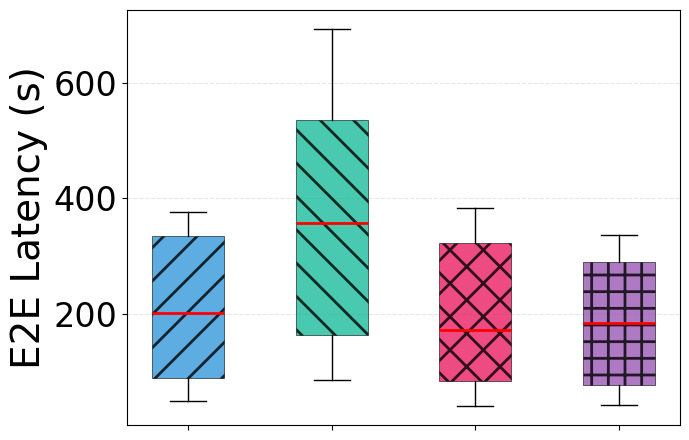

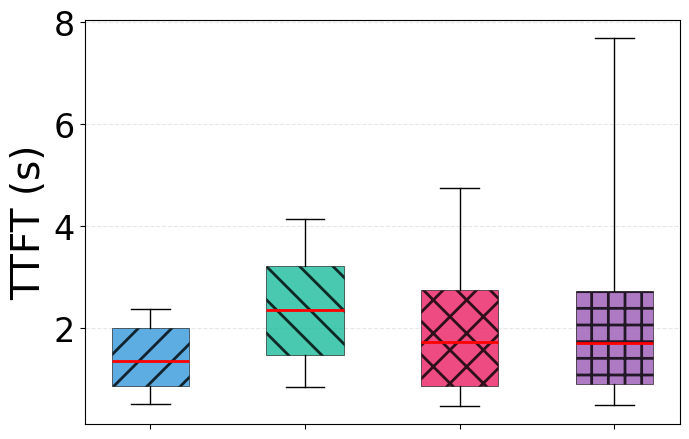

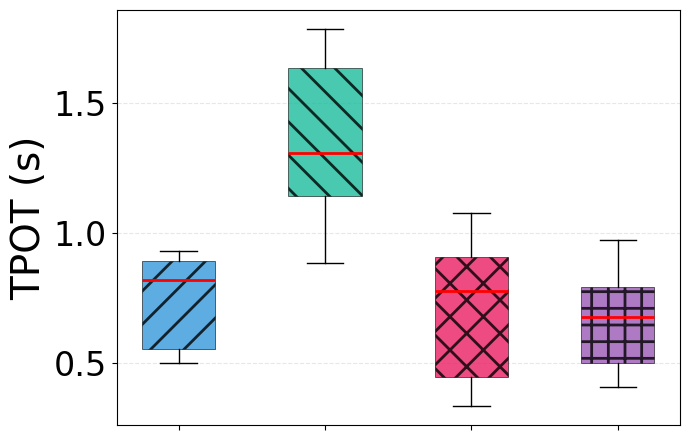

In [2]:
plot_online_boxplot('llama3-70b', source='json')

  AlpaServe   : loaded from JSON
  HexGen      : loaded from JSON
  ShuntServe  : loaded from JSON
  vLLM        : loaded from JSON


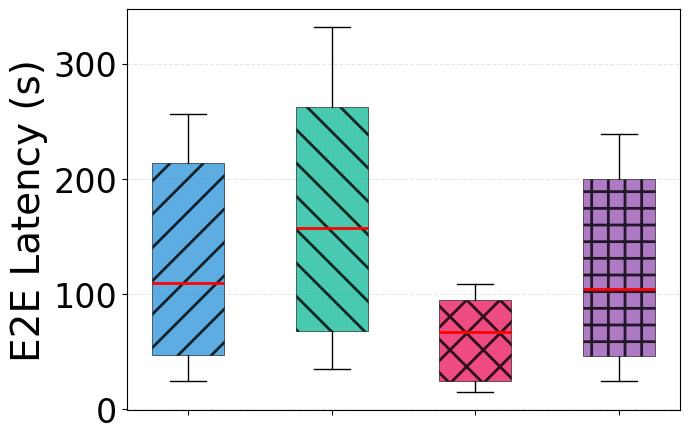

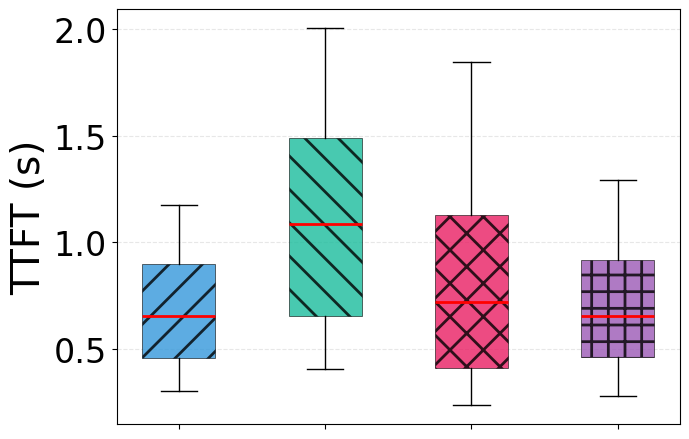

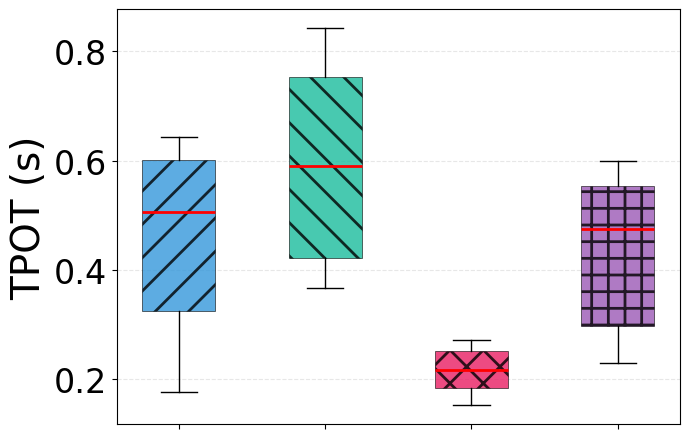

In [3]:
plot_online_boxplot('qwen3-32b', source='json')

In [4]:
def plot_scalability_boxplot(model_small='qwen3-32b', model_large='llama3-70b',
                             metric_indices=(1, 2)):
    """Plot paired boxplots (small model vs large model) to show scalability.

    Each metric is saved as a separate PDF for subfloat usage in LaTeX.
    Each system gets two side-by-side boxplots: lighter=small model, darker+hatch=large model.

    metric_indices: tuple of METRICS indices to plot (default: TTFT=1, TPOT=2)
    """
    jscale = 0.001  # ms -> s

    def load_json_stats(model):
        model_dir = os.path.join(BASE_DIR, 'online', model, 'json')
        stats = {}
        for jp in sorted(glob.glob(os.path.join(model_dir, '*.json'))):
            stem = pathlib.Path(jp).stem.replace('online_', '')
            sys_name = SYSTEM_NAME_MAP.get(stem)
            if sys_name is None:
                continue
            with open(jp) as f:
                d = json.load(f)
            stats[sys_name] = {}
            for mi, (_, json_key, _, _, _, _) in enumerate(METRICS):
                p = d[json_key]
                stats[sys_name][mi] = {
                    'whislo': p['10'] * jscale, 'q1': p['25'] * jscale,
                    'med':    p['50'] * jscale,  'q3': p['75'] * jscale,
                    'whishi': p['90'] * jscale,
                }
        return stats

    stats_small = load_json_stats(model_small)
    stats_large = load_json_stats(model_large)

    systems = [s for s in SYSTEM_ORDER if s in stats_small and s in stats_large]
    if not systems:
        print('No overlapping systems found.')
        return

    box_width = 0.3
    pair_gap = 0.05

    for mi in metric_indices:
        _, _, ylabel, file_suffix, _, _ = METRICS[mi]

        fig, ax = plt.subplots(figsize=(7, 5))

        text_info = []
        for i, sys_name in enumerate(systems):
            style = SYSTEM_STYLE[sys_name]
            center = i
            pos_small = center - (box_width / 2 + pair_gap / 2)
            pos_large = center + (box_width / 2 + pair_gap / 2)

            # --- Small model (lighter, no hatch) ---
            s = stats_small[sys_name][mi]
            bp_small = ax.bxp(
                [{'whislo': s['whislo'], 'q1': s['q1'], 'med': s['med'],
                  'q3': s['q3'], 'whishi': s['whishi'], 'fliers': []}],
                positions=[pos_small], widths=box_width,
                showfliers=False, patch_artist=True, manage_ticks=False,
            )
            for box in bp_small['boxes']:
                box.set_facecolor(style['color']); box.set_alpha(0.7)
                box.set_edgecolor('black'); box.set_linewidth(0.5)
            for med in bp_small['medians']:
                med.set_color('#FFD700'); med.set_linewidth(2)
            for w in bp_small['whiskers']:
                w.set_color('black'); w.set_linewidth(1)
            for c in bp_small['caps']:
                c.set_color('black'); c.set_linewidth(1)

            # --- Large model (full color, with hatch) ---
            l = stats_large[sys_name][mi]
            bp_large = ax.bxp(
                [{'whislo': l['whislo'], 'q1': l['q1'], 'med': l['med'],
                  'q3': l['q3'], 'whishi': l['whishi'], 'fliers': []}],
                positions=[pos_large], widths=box_width,
                showfliers=False, patch_artist=True, manage_ticks=False,
            )
            for box in bp_large['boxes']:
                box.set_facecolor(style['color']); box.set_alpha(0.8)
                box.set_edgecolor('black'); box.set_linewidth(0.5)
                box.set_hatch(style['hatch'])
            for med in bp_large['medians']:
                med.set_color('#FFD700'); med.set_linewidth(2)
            for w in bp_large['whiskers']:
                w.set_color('black'); w.set_linewidth(1)
            for c in bp_large['caps']:
                c.set_color('black'); c.set_linewidth(1)

            ratio = l['med'] / s['med'] if s['med'] > 0 else float('inf')
            large_left = pos_large - box_width / 2
            text_info.append((large_left + 0.00, l['med'], ratio))

        # Compute uniform y offset (2.5% of y-axis range)
        y_lo, y_hi = ax.get_ylim()
        y_offset = (y_hi - y_lo) * 0.025

        for text_x, med_y, ratio in text_info:
            ax.text(text_x, med_y + y_offset, f'$\\times${ratio:.1f}',
                    ha='right', va='bottom', fontsize=20,
                    fontweight='bold', color='#B22222')

        # --- Vertical separator lines between systems ---
        for i in range(len(systems) - 1):
            ax.axvline(x=i + 0.5, color='gray', linestyle='--',
                       linewidth=0.8, alpha=0.5)

        ax.set_ylabel(ylabel, fontsize=YLABEL_FONTSIZE)
        ax.set_xticks(range(len(systems)))
        ax.set_xticklabels(systems, fontsize=20, rotation=0)
        ax.tick_params(axis='y', labelsize=YTICK_FONTSIZE)
        ax.set_axisbelow(True)

        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, f'online_{file_suffix}.pdf'),
                    format='pdf', bbox_inches='tight')
        plt.show()

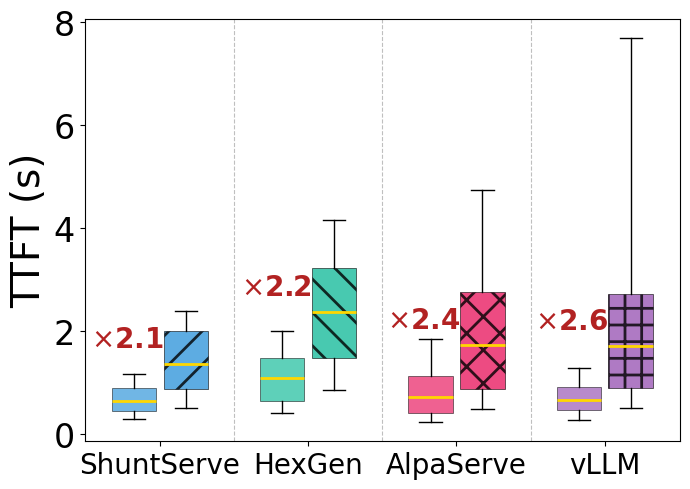

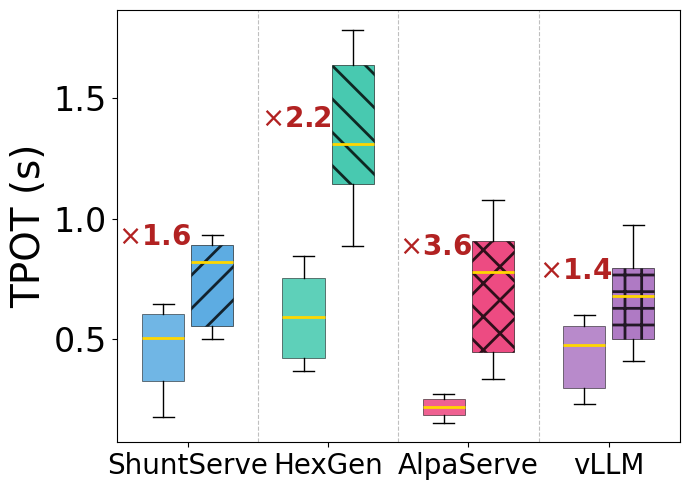

In [5]:
plot_scalability_boxplot()

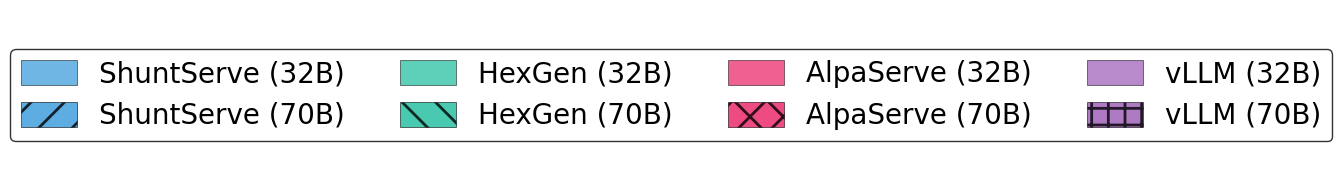

In [6]:
# === Scalability legend (32B vs 70B distinction) ===

fig, ax = plt.subplots(figsize=(14, 2))
ax.axis('off')

legend_handles = []
for s in SYSTEM_ORDER:
    style = SYSTEM_STYLE[s]
    # Light box = 32B
    legend_handles.append(mpatches.Patch(
        facecolor=style['color'], label=f'{s} (32B)', alpha=0.7,
        edgecolor='black', linewidth=0.5,
    ))
    # Dark box with hatch = 70B
    legend_handles.append(mpatches.Patch(
        facecolor=style['color'], label=f'{s} (70B)', alpha=0.8,
        edgecolor='black', linewidth=0.5, hatch=style['hatch'],
    ))

ax.legend(handles=legend_handles, loc='center',
          ncol=4, fontsize=20,
          frameon=True, handlelength=2, handleheight=1, edgecolor='black')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'online_legend.pdf'),
            format='pdf', bbox_inches='tight')
plt.show()

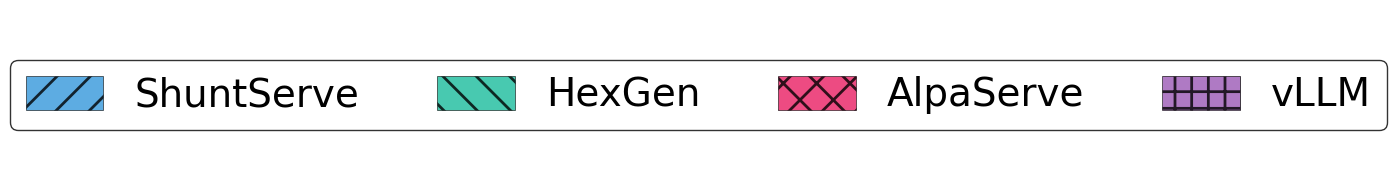

In [7]:
# === Legend (separate, for composing in paper) ===

fig, ax = plt.subplots(figsize=(12, 2))
ax.axis('off')

legend_patches = [
    mpatches.Patch(
        facecolor=SYSTEM_STYLE[s]['color'], label=s, alpha=0.8,
        edgecolor='black', linewidth=0.5, hatch=SYSTEM_STYLE[s]['hatch']
    )
    for s in SYSTEM_ORDER
]

ax.legend(handles=legend_patches, loc='center',
          ncol=len(legend_patches), fontsize=LEGEND_FONTSIZE,
          frameon=True, handlelength=2, handleheight=1, edgecolor='black')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_placement_legend.pdf'),
            format='pdf', bbox_inches='tight')
plt.show()

  AlpaServe   :   609 completed in [0-15) min
  HexGen      :  1244 completed in [0-15) min
  ShuntServe  :   611 completed in [0-15) min
  vLLM        :   617 completed in [0-15) min


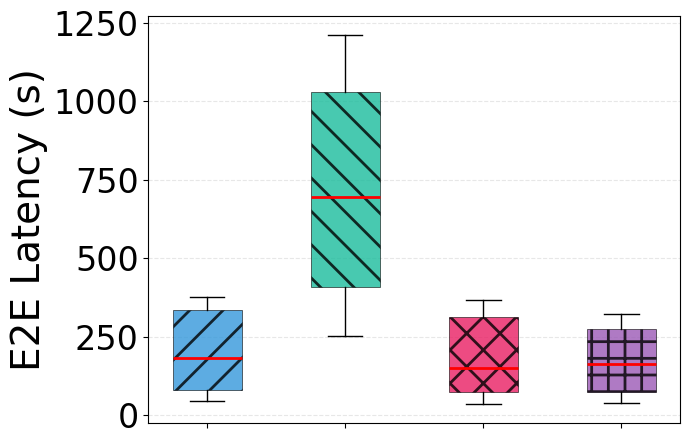

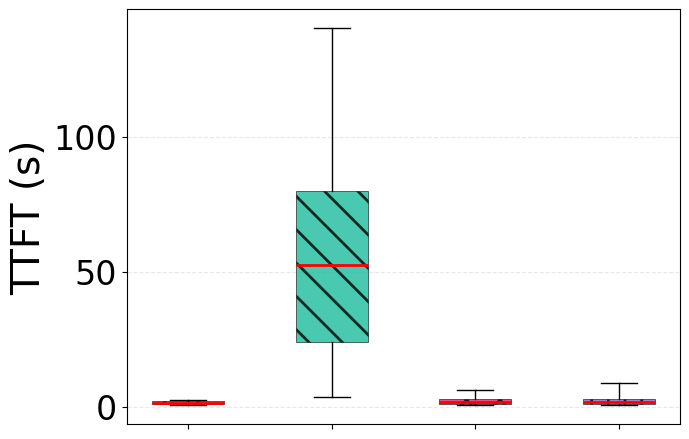

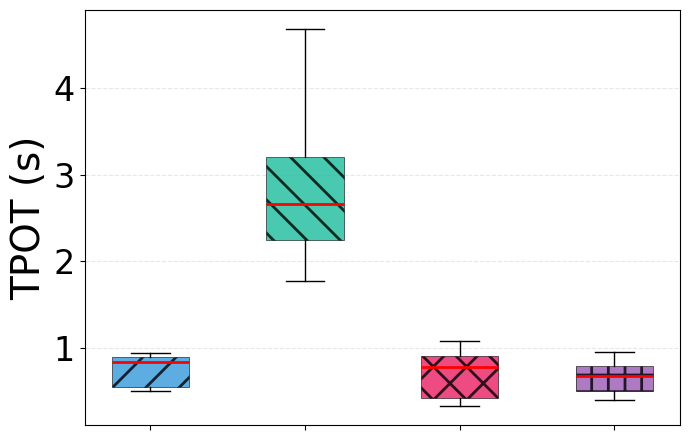

In [8]:
plot_online_boxplot('llama3-70b', source='csv', t_start_min=0, t_end_min=15)

  AlpaServe   :  2238 completed in [0-15) min
  HexGen      :  1244 completed in [0-15) min
  ShuntServe  :  2130 completed in [0-15) min
  vLLM        :  2139 completed in [0-15) min


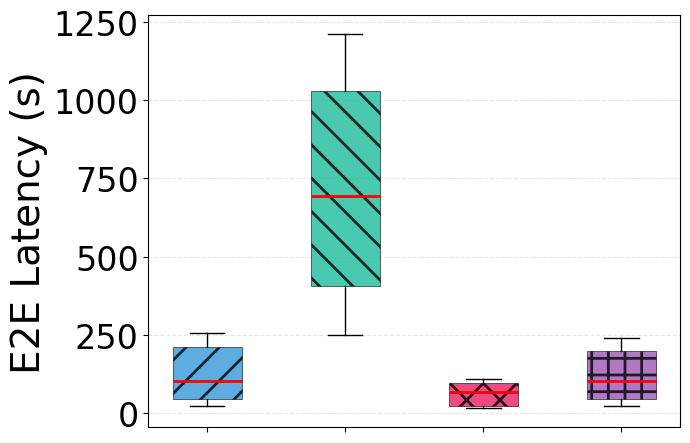

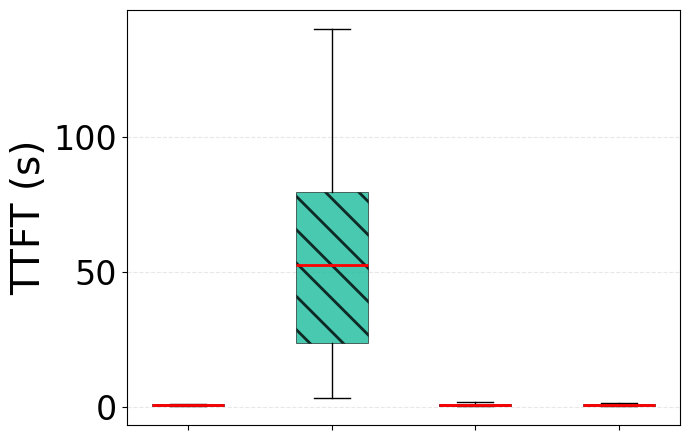

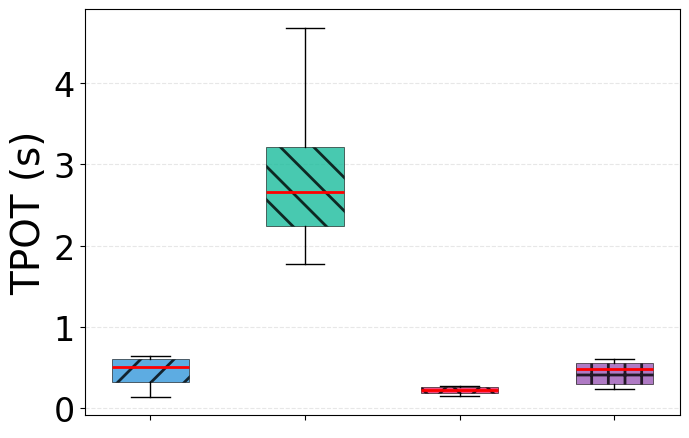

In [9]:
plot_online_boxplot('qwen3-32b', source='csv', t_start_min=0, t_end_min=15)